# Day 7: EDA of AFL merged Player Dataset

### Requirements
Gotta answer the following questions
1. Which teams have played the most games?
2. What is the distribution of player ages (last_age)?
3. Which player positions/teams have the highest number of players? (Use player_teams since no position column exists.)
4. How does player weight vary across different teams?
5. Which teams have the highest average fantasy points?
6. Who are the Top 15 goal scorers?
7. How many records are available for each season?

In [28]:
#import libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [29]:
df = pd.read_csv("merged_players.csv")

In [30]:
df.isnull().sum().sort_values(ascending = False)

player_common_names    24173
profile_pic            20015
player_teams             810
weight                     3
player_id                  0
                       ...  
last_name                  0
height                     0
last_age                   0
last_date                  0
player_link                0
Length: 69, dtype: int64

Okay so we dont need to know the missing common names, profile pictures as well as player teams since some of them weren't even part of any teams so its alright

lets look at weight though. It needs some work. There are 3 NaN values

In [31]:
df["weight"].sort_values()

18981     63.0
16699     64.0
16700     64.0
16704     64.0
16702     64.0
         ...  
25021    118.0
25036    118.0
19272      NaN
24961      NaN
24962      NaN
Name: weight, Length: 25081, dtype: float64

### Cleaning Weight

In [32]:
df['weight'] = df['weight'].fillna(df['weight'].median())

In [33]:
df['weight'].isna().sum()

np.int64(0)

Nice!

# **Fulfilling the Requirement**
## 1. Which teams have played the most games?
**Business question:** Which clubs have the most recorded player activity across all seasons?

                             team  games_played
0                    Geelong Cats         16834
1               West Coast Eagles         16518
2                Essendon Bombers         16462
3       North Melbourne Kangaroos         16336
4             Collingwood Magpies         16298
5                    Sydney Swans         16173
6                 St Kilda Saints         16116
7                Western Bulldogs         16080
8                  Adelaide Crows         16018
9                 Richmond Tigers         16010
10                  Carlton Blues         15968
11               Melbourne Demons         15614
12                 Hawthorn Hawks         15576
13              Fremantle Dockers         14946
14                 Brisbane Lions         14929
15            Port Adelaide Power         14729
16                Gold Coast Suns          7375
17  Greater Western Sydney Giants          7271
18                 Brisbane Bears          1469
19                  Fitzroy Lions       

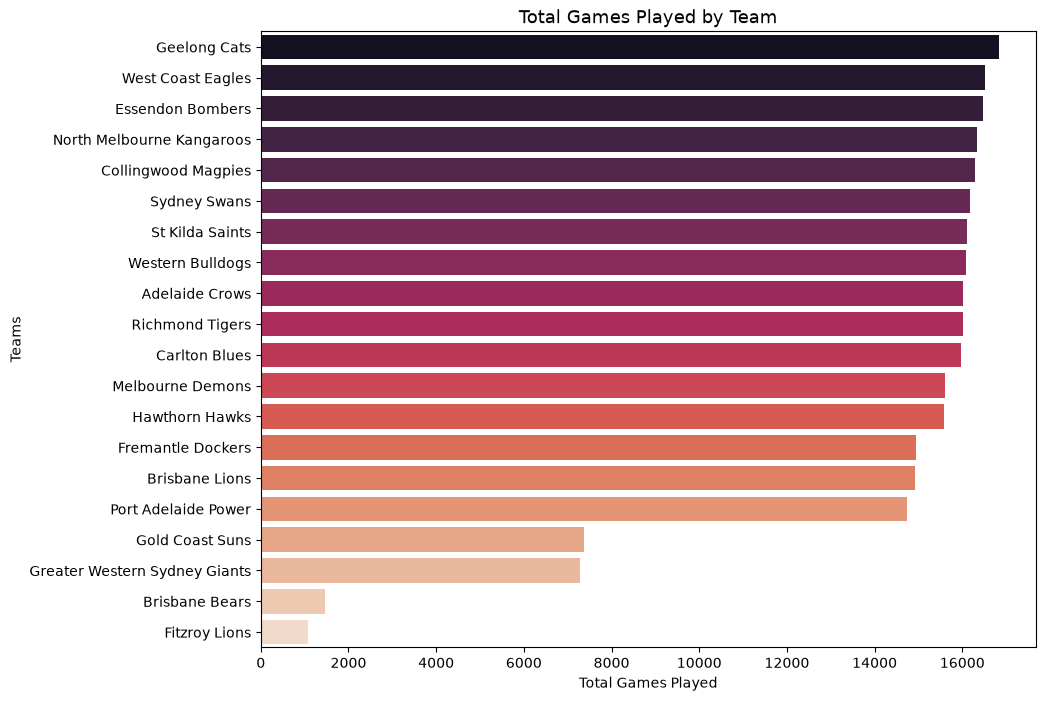

In [50]:
games = df.groupby('team')['games_played'].sum().sort_values(ascending=False).reset_index()
print(games)
plt.figure(figsize = (10,8))
sns.barplot(data=games, y='team', x='games_played', palette='rocket')
plt.title('Total Games Played by Team', fontsize=13)
plt.xlabel('Total Games Played')
plt.ylabel("Teams")
plt.show()


**Observations**
1. Geelong Cats lead the league with a total of 16834 games played.
2. West Coast Eagles (16,518) and Essendon Bombers (16,462) follow closely behind.
3. Most of the top ten teams have played a very similar, high number of games (all over 16,000).

**Business Insight**: Spend your advertising budget on Geelong, West Coast, and Essendon. Because these teams play the most games, your brand will get seen by fans more often, giving you the best return on your money.


## 2. What is the distribution of player ages?
**Business Question:** At what age should team managers start looking for young replacement players before older players retire or slow down?

Last Age Desc:
 count    25081.000000
mean        28.775527
std          3.880184
min         18.000000
25%         26.000000
50%         29.000000
75%         32.000000
max         40.000000
Name: last_age, dtype: float64


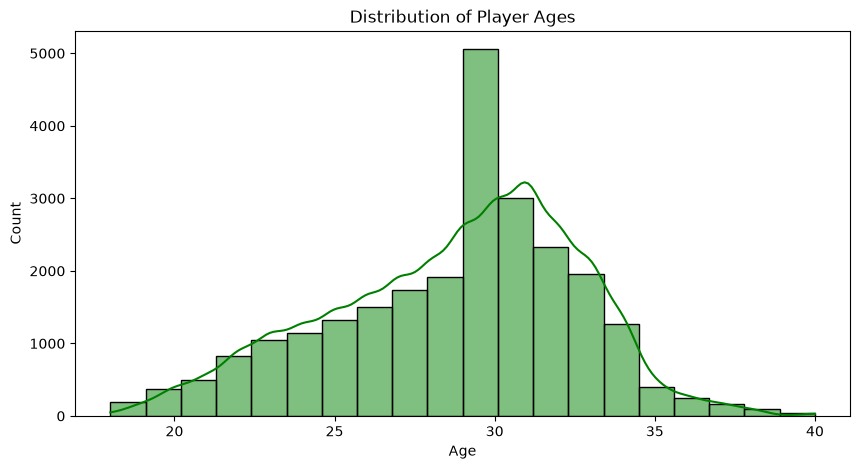

In [51]:
print("Last Age Desc:\n", df['last_age'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['last_age'], bins=20, kde=True, color='green')   #since we are talking about distributioon we better use a histogram
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()



**Observations**
1. The average player is around **28.7 years old** during their last active season or 28
2. The number of active players drops very quickly right after they turn **30 years old**.
3. A huge number of players are grouped between the ages of 29 and 31.

**Business Insight**:Teams should avoid giving long, expensive contracts to players who are 29 or older. Managers need to draft fresh, young talent early so the team stays strong when players hit the "age 30 wall" and retire.

## 3. Which player positions/teams have the highest number of players?
**Business Question:** Which clubs have the biggest networks of past and present players to help us run local business promotions?

player_teams
{West Coast Eagles}                                               996
{Essendon Bombers}                                                962
{Sydney Swans}                                                    921
{Geelong Cats}                                                    834
{Adelaide Crows}                                                  793
                                                                 ... 
{Carlton Blues,Greater Western Sydney Giants,Sydney Swans}          6
{Fremantle Dockers,Port Adelaide Power,Western Bulldogs}            6
{Fremantle Dockers,Melbourne Demons,North Melbourne Kangaroos}      6
{Adelaide Crows,Port Adelaide Power,West Coast Eagles}              6
{Fitzroy Lions,Port Adelaide Power,Richmond Tigers}                 6
Name: count, Length: 309, dtype: int64


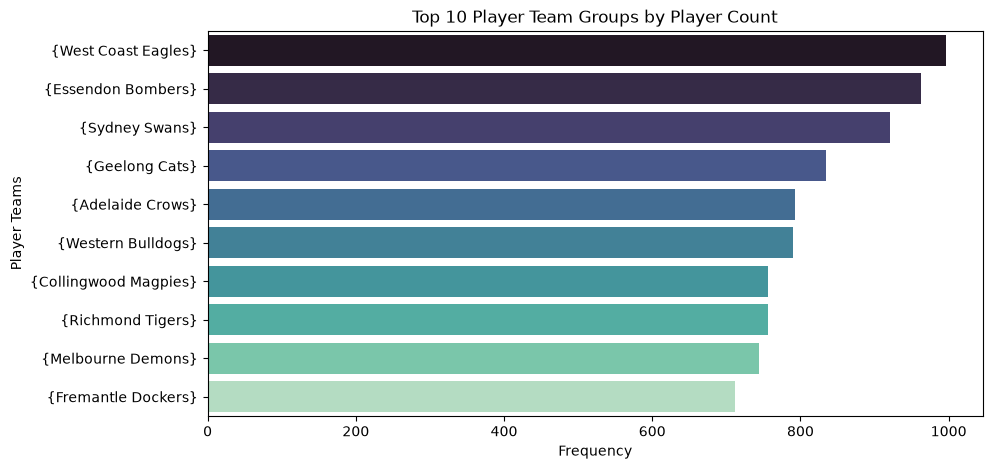

In [44]:
top_teams = df['player_teams'].value_counts().head(10).index
print(df['player_teams'].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['player_teams'].isin(top_teams)], y=df['player_teams'], palette='mako', order=top_teams)
plt.title('Top 10 Player Team Groups by Player Count')

plt.ylabel("Player Teams")
plt.xlabel("Frequency")
plt.show()

**Observations**
1. The **West Coast Eagles** have the largest player group with **996 player records**.
2. **Essendon Bombers** are second with **962 records**.
3. **Sydney Swans** are third with **921 records**.

**Business Insight**: If you want to hire popular player ambassadors for local marketing campaigns, focus on West Coast and Essendon. They have the biggest groups of current and former players, giving you more choices to find a trusted face for your brand.

## 4. How does player weight vary across different teams?
**Business Question:** Do different teams prioritize weight or physical size differences across their rosters that are active?

team
Gold Coast Suns                  85.750000
Richmond Tigers                  86.766667
Western Bulldogs                 86.960106
Port Adelaide Power              87.049401
Adelaide Crows                   87.158763
Hawthorn Hawks                   87.166435
North Melbourne Kangaroos        87.354067
Melbourne Demons                 87.397091
Greater Western Sydney Giants    87.428765
Fitzroy Lions                    87.520548
Carlton Blues                    87.696566
St Kilda Saints                  87.738726
Sydney Swans                     87.742839
Essendon Bombers                 87.865908
Fremantle Dockers                88.062117
Brisbane Lions                   88.312233
West Coast Eagles                88.324572
Collingwood Magpies              88.360985
Brisbane Bears                   88.429688
Geelong Cats                     89.073302
Name: weight, dtype: float64


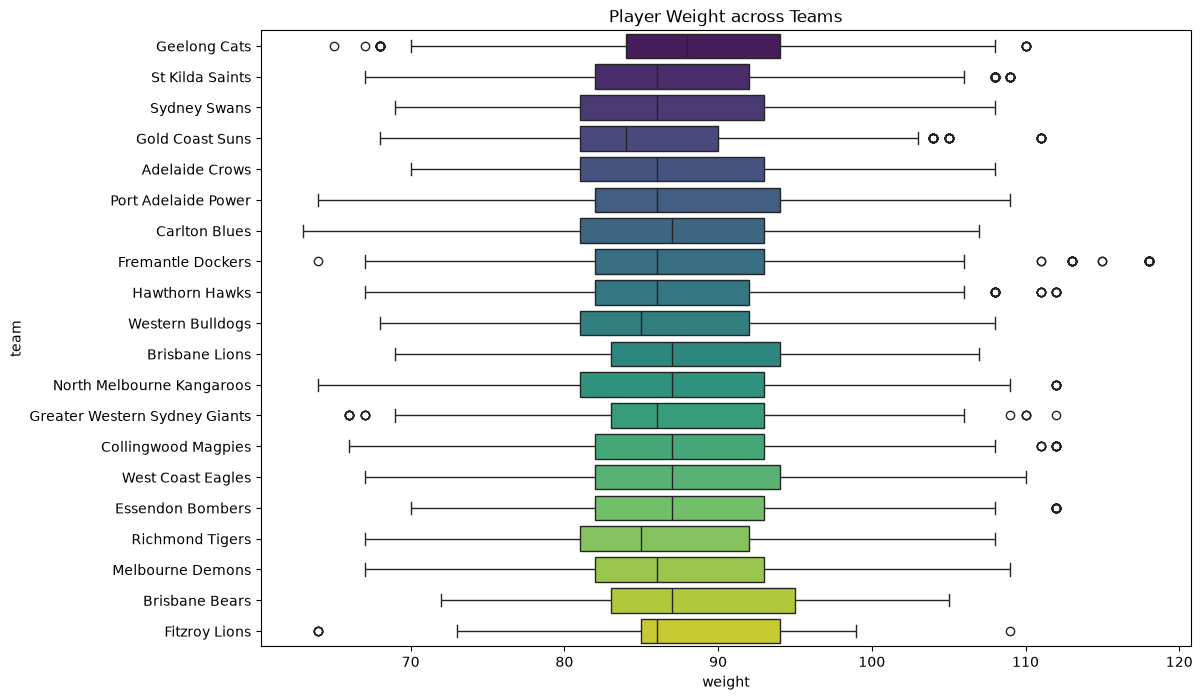

In [46]:
print(df.groupby('team')['weight'].mean().sort_values())
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='weight', y='team', palette='viridis')
plt.title('Player Weight across Teams')
plt.show()

**Observations**:
1. Player weights across the whole league are almost exactly the same, usually between **85 kg and 90 kg**.
2. The **Gold Coast Suns** have the lightest average roster at **85.75 kg**.
3. The **Geelong Cats** are slightly heavier on average.

**Business Insights**: Since almost every team weighs the same, trying to make players bigger won't give us a real advantage. Coaches should focus training on speed, skill, and stamina instead of extra weight, using a faster, lighter style like the Gold Coast Suns.

## 5. Which teams have the highest average fantasy points?
**Business Question:** Which teams should fantasy sports platforms and gaming apps feature on their homepages to get fans online and playing? 


                            team  avg_fantasy_points
0                 Hawthorn Hawks           62.627368
1  Greater Western Sydney Giants           62.549525
2                   Geelong Cats           62.186412
3            Collingwood Magpies           60.885936
4                St Kilda Saints           60.579957
5               Essendon Bombers           60.315117
6                 Adelaide Crows           60.083849
7               Western Bulldogs           59.951662
8              Fremantle Dockers           59.917485
9                Gold Coast Suns           59.587987


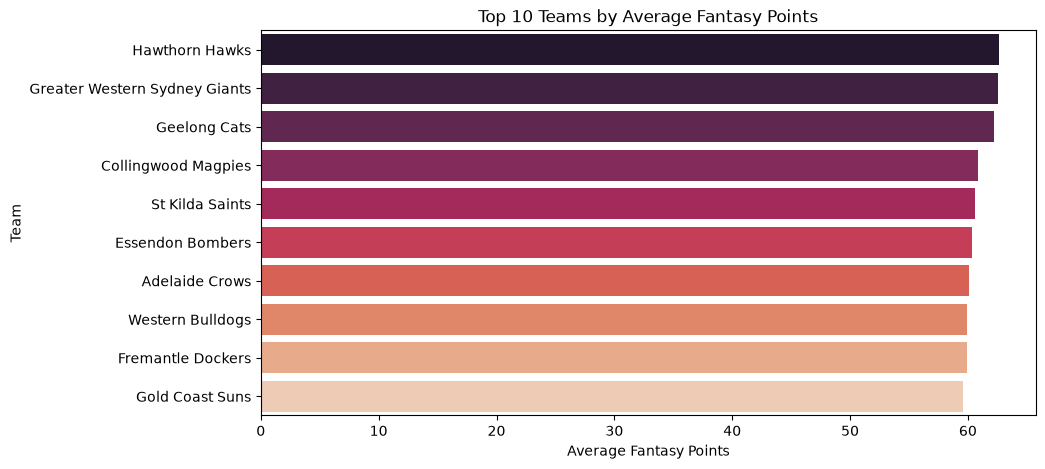

In [47]:
avg_fantasy_pts = df.groupby('team')['avg_fantasy_points'].mean().sort_values(ascending=False).head(10).reset_index()
print(avg_fantasy_pts)
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_fantasy_pts, x='avg_fantasy_points', y='team', palette='rocket')
plt.title('Top 10 Teams by Average Fantasy Points')
plt.xlabel("Average Fantasy Points")
plt.ylabel("Team")
plt.show()

**Observations**:
1. **Hawthorn Hawks** players score the most fantasy value, averaging **62.63 points** per game.
2. **GWS Giants** are a close second at **62.55 points**.
3. **Geelong Cats** are third at **62.19 points**.

**Business Insights**:Put Hawthorn and GWS Giants matches at the top of your apps and sports news pages. Players on these teams get a lot of stats, making their games the most exciting for fans who love tracking fantasy scores.


## 6. Who are the Top 15 goal scorers?
**Business Question:** Who are the high-impact star franchise players that dominate the scoreboard and can help sell merchandise?

6. Top 15 Goal Scorers:
       player_full_name   goals
0         Tony_Lockett  1360.0
1       Lance_Franklin  1066.0
2       Matthew_Lloyd0   926.0
3   Matthew_Richardson   800.0
4          Tom_Hawkins   796.0
5        Jack_Riewoldt   787.0
6        Saverio_Rocca   748.0
7           Barry_Hall   746.0
8       Jeremy_Cameron   736.0
9          Wayne_Carey   727.0
10       Josh_Kennedy0   723.0
11       Nick_Riewoldt   718.0
12     Matthew_Pavlich   700.0
13       Taylor_Walker   680.0
14         Eddie_Betts   640.0


Text(0, 0.5, 'Player Names')

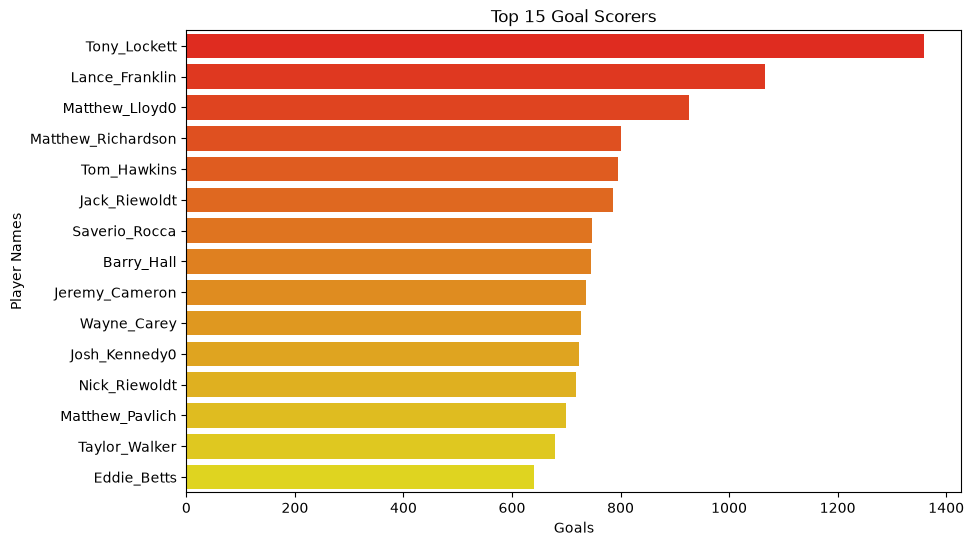

In [39]:
top_scorers = df.groupby('player_full_name')['goals'].sum().sort_values(ascending=False).head(15).reset_index()
print("6. Top 15 Goal Scorers:\n", top_scorers)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_scorers, x='goals', y='player_full_name', palette='autumn')
plt.title('Top 15 Goal Scorers')
plt.xlabel("Goals")
plt.ylabel("Player Names")


**Observations**:

1. **Tony Lockett** is the all-time highest goal scorer with **1,360 goals**.
2. **Lance Franklin** is the top modern star with **1,066 goals**.
3. **Matthew Lloyd** is third with **926 goals**.

**Business insight:** Feature Lockett, Franklin, and Lloyd. High-scoring forwards are loved by fans of all ages, which means their gear is always the easiest to sell for a high profit.

## 7. How many records are available for each season?
**Business Question:** What year should our data team use as a starting cutoff point so our player prediction models are accurate?

7. Records per season:
     year  count
0   1983      2
1   1984      2
2   1985      7
3   1986     15
4   1987     29
5   1988     52
6   1989     71
7   1990     93
8   1991    136
9   1992    183
10  1993    235
11  1994    321
12  1995    416
13  1996    489
14  1997    587
15  1998    673
16  1999    742
17  2000    760
18  2001    743
19  2002    729
20  2003    726
21  2004    741
22  2005    755
23  2006    754
24  2007    755
25  2008    761
26  2009    765
27  2010    768
28  2011    821
29  2012    864
30  2013    867
31  2014    848
32  2015    853
33  2016    843
34  2017    842
35  2018    840
36  2019    842
37  2020    838
38  2021    872
39  2022    874
40  2023    859
41  2024    850
42  2025    858


Text(0.5, 1.0, 'Number of Records available per Season')

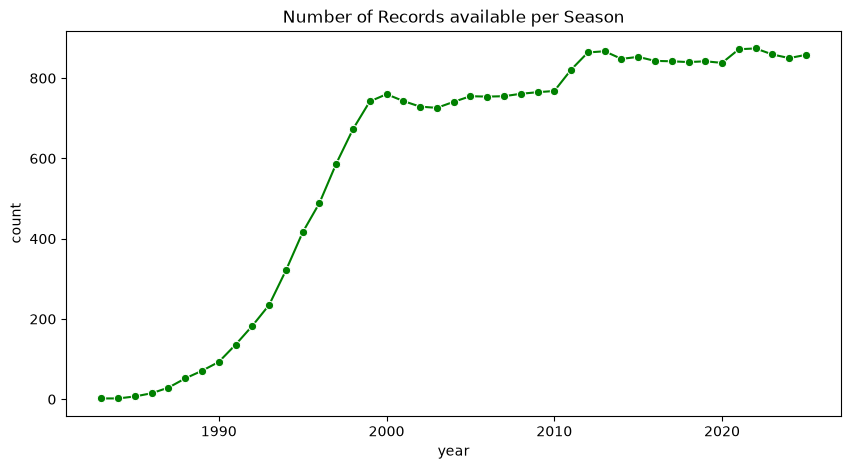

In [40]:
records= df['year'].value_counts().sort_index().reset_index()
print("7. Records per season:\n", records)
plt.figure(figsize = (10,5))
sns.lineplot(data=records, x='year', y='count', marker='o', color='green')
plt.title('Number of Records available per Season')


**Observation:**
* Years between 1983 and 1990 have very poor data, tracking fewer than 100 player records a year.
* Data collection got much better in the mid-1990s and stabilized at over **800 records a year** starting in 2000.
* The years 2012 to 2025 have the most complete and tidy data.

**Business Insights:** Delete or ignore all player stats from before the year 2000 when building computer models to predict player performance. Using data from 2000 onward ensures your numbers are accurate and won't be messed up by old, missing files tep.